# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [35]:
%pip install pandas numpy matplotlib

389681.19s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Evaluation on a single symbol

Fetching AWEBTC data...
Fetching ADR data...
ADR data fetched successfully
Building features...
Dataset shape: (485, 38)
Date range: 2025-09-20 11:15:00 to 2025-09-25 12:15:00

=== DATA ANALYSIS ===
Price change statistics:
count    485.000000
mean       0.000977
std        0.013557
min       -0.063636
25%        0.000000
50%        0.000000
75%        0.000000
max        0.129032
Name: price_change, dtype: float64

Volume ratio statistics:
count    485.000000
mean       1.027181
std        1.800933
min        0.000000
25%        0.000000
50%        0.132417
75%        1.181469
max        8.000000
Name: volume_ratio, dtype: float64

Candles with >1% price increase: 88
Candles with >2% price increase: 26

Label distribution: {0: np.int64(460), 1: np.int64(25)}
Spike detection rate: 0.0515

First 10 detected spikes:
              timestamp          open         close  price_change  \
80  2025-09-21 07:15:00  6.900000e-07  6.900000e-07      0.014706   
83  2025-09-21 08:00:00  6.900000e-0

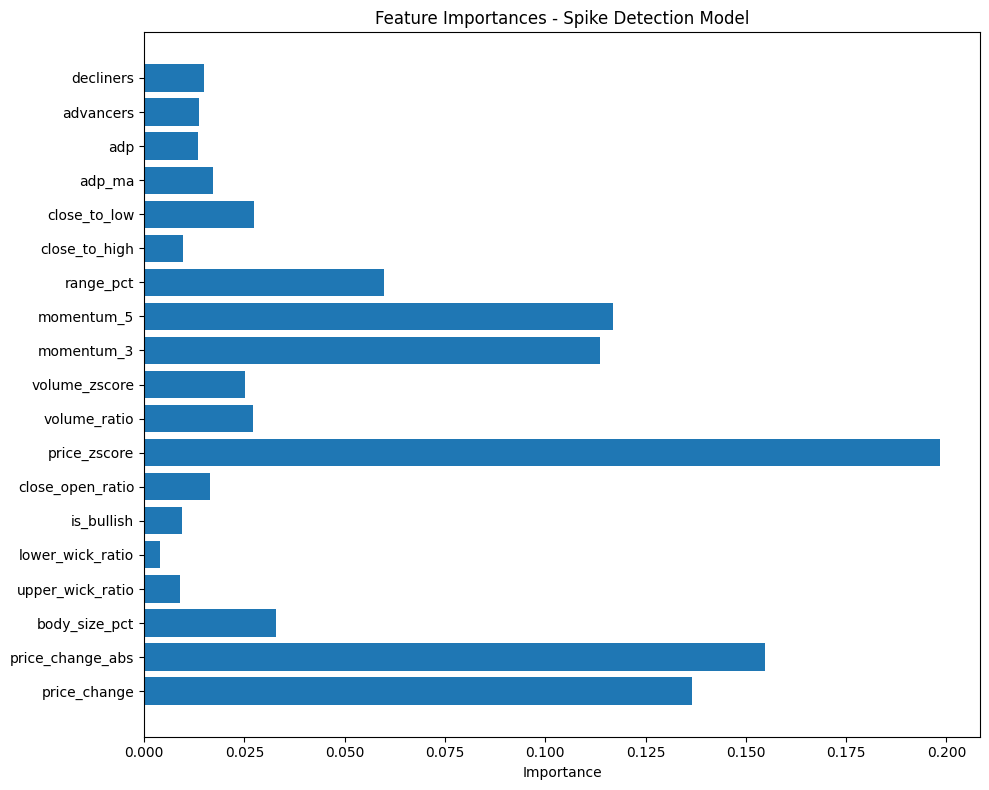


=== PLOTTING RESULTS ===
Plotting 25 detected spikes


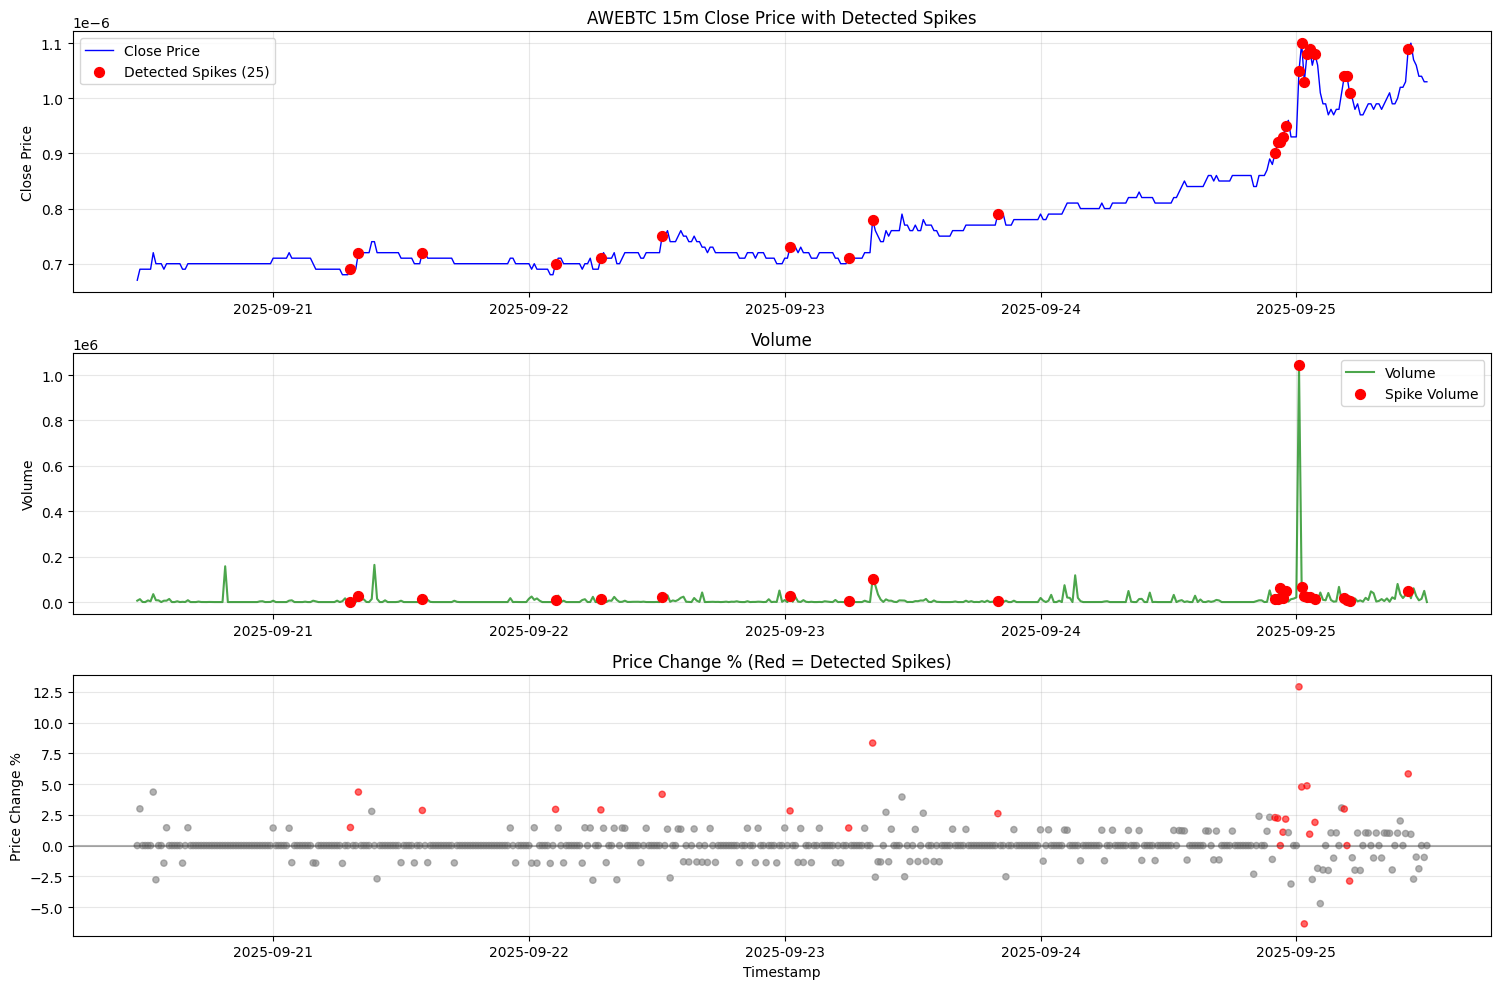


=== SPIKE DETAILS ===
              timestamp  close  price_change_pct  volume_ratio
80  2025-09-21 07:15:00    0.0              1.47        0.0434
83  2025-09-21 08:00:00    0.0              4.35        4.5896
107 2025-09-21 14:00:00    0.0              2.86        7.8723
157 2025-09-22 02:30:00    0.0              2.94        2.4304
174 2025-09-22 06:45:00    0.0              2.90        2.0708
197 2025-09-22 12:30:00    0.0              4.17        7.1908
245 2025-09-23 00:30:00    0.0              2.82        2.2611
267 2025-09-23 06:00:00    0.0              1.43        2.5840
276 2025-09-23 08:15:00    0.0              8.33        7.4027
323 2025-09-23 20:00:00    0.0              2.60        2.0995
427 2025-09-24 22:00:00    0.0              2.27        1.0113
428 2025-09-24 22:15:00    0.0              2.22        1.1440
429 2025-09-24 22:30:00    0.0              0.00        3.1524
430 2025-09-24 22:45:00    0.0              1.09        0.8012
431 2025-09-24 23:00:00    0.0  

['../checkpoints/spikehunter_model_v1.pkl']

In [36]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

symbol = "AWEBTC"

# Set fixed thresholds for both training and production (example: 0.02 for price, 2.0 for volume)
FIXED_PRICE_THRESHOLD = 0.025
FIXED_VOLUME_THRESHOLD = 2.5

# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "qav",
            "num_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    df = df[["open_time", "open", "high", "low", "close", "volume"]].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


# --- Step 2: Fetch ADR data ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame(
        {
            "timestamp": pd.to_datetime(j["data"]["timestamp"]),
            "adp_ma": j["data"]["adp_ma"],
            "advancers": j["data"]["advancers"],
            "decliners": j["data"]["decliners"],
            "adp": j["data"]["adp"],
            "total_volume": j["data"]["total_volume"],
        }
    )
    return df_adr


# --- Step 3: Spike labeling with multiple detection methods ---
def label_spike_patterns(
    df,
    price_thresh=0.015,
    vol_ratio_thresh=1.5,
    window=12,
    momentum_thresh=0.01,
    rsi_oversold=30,
    use_adr_filter=False,
    adp_col="adp",
    adp_thresh=0.5,
):
    """ 
    Spike detection with multiple methods:
    1. Price + Volume spike detection
    2. Momentum-based detection
    3. RSI oversold reversal detection
    4. Optional ADR filtering
    """
    labels = []

    # Calculate RSI
    df = calculate_rsi(df, window=14)

    for i in range(len(df)):
        if i < window:
            labels.append(0)
            continue

        label = 0

        # Method 1: Traditional price + volume spike
        prev_close = df.loc[i - 1, "close"]
        curr_close = df.loc[i, "close"]
        price_change = (curr_close - prev_close) / prev_close

        # Use smaller rolling window for volume comparison with microcaps
        vol_window = min(window, i)
        avg_vol = df.loc[max(0, i - vol_window) : i - 1, "volume"].mean()
        vol_ratio = df.loc[i, "volume"] / (avg_vol + 1e-6)

        if price_change > price_thresh and vol_ratio > vol_ratio_thresh:
            label = 1

        # Method 2: Momentum-based detection (consecutive positive moves)
        if not label and i >= 3:  # Reduced from window requirement
            recent_changes = df.loc[max(0, i - 3) : i, "price_change"]
            if (
                len(recent_changes) >= 3
                and (recent_changes > momentum_thresh).sum() >= 2
            ):
                total_momentum = recent_changes.sum()
                if total_momentum > price_thresh:
                    label = 1

        # Method 3: RSI oversold reversal
        if not label and i >= 14:  # RSI requires 14 periods minimum
            prev_rsi = df.loc[i - 1, "rsi"]
            curr_rsi = df.loc[i, "rsi"]
            if (
                prev_rsi < rsi_oversold
                and curr_rsi > prev_rsi + 5
                and price_change > 0.005
            ):
                label = 1

        # Optional ADR filter (only apply if use_adr_filter is True)
        if label and use_adr_filter:
            adp_val = df.loc[i, adp_col] if adp_col in df.columns else 0.5
            if pd.isna(adp_val) or adp_val >= adp_thresh:
                label = 0

        labels.append(label)

    df = df.copy()
    df["label"] = labels
    return df


def calculate_rsi(df, window=14):
    """Calculate RSI indicator"""
    df = df.copy()
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df["rsi"] = 100 - (100 / (1 + rs))
    return df


# --- Step 4: Enhanced feature engineering ---
def add_enhanced_features(df_price, df_adr=None, window=12):
    df = df_price.copy()
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Adapt window size for small datasets
    effective_window = min(window, len(df) // 8)  # More conservative for microcaps
    if effective_window < 3:
        effective_window = 3  # Absolute minimum

    # Merge ADR data if available
    if df_adr is not None:
        df_adr = df_adr.sort_values("timestamp").reset_index(drop=True)
        df = pd.merge_asof(df, df_adr, on="timestamp", direction="backward")
        df[["adp", "adp_ma", "advancers", "decliners", "total_volume"]] = df[
            ["adp", "adp_ma", "advancers", "decliners", "total_volume"]
        ].fillna(method="bfill")

    # Basic price features
    df["price_change"] = df["close"].pct_change()
    df["price_change_abs"] = df["price_change"].abs()

    # Candle features
    df["body_size"] = abs(df["close"] - df["open"])
    df["body_size_pct"] = df["body_size"] / df["open"]
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["total_range"] = df["high"] - df["low"]
    df["range_pct"] = df["total_range"] / df["open"]

    # Trend and momentum features
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)

    # Rolling features - use effective window
    df["price_ma"] = df["close"].rolling(window=effective_window).mean()
    df["price_std"] = df["close"].rolling(window=effective_window).std()
    df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)

    # Volume features
    df["volume_ma"] = df["volume"].rolling(window=effective_window).mean()
    df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
    df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
        df["volume"].rolling(window=effective_window).std() + 1e-6
    )

    # Add new volume percentile feature
    df["volume_percentile"] = (
        df["volume"].rolling(window=effective_window * 2).rank(pct=True)
    )

    # Momentum indicators
    df["momentum_3"] = df["close"].pct_change(3)
    df["momentum_5"] = df["close"].pct_change(5)

    # High/Low features
    df["high_low_ratio"] = df["high"] / df["low"]
    df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
    df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)

    df = df.dropna().reset_index(drop=True)

    # Apply more conservative spike labeling with higher thresholds
    df = label_spike_patterns(
        df,
        price_thresh=FIXED_PRICE_THRESHOLD,
        vol_ratio_thresh=FIXED_VOLUME_THRESHOLD,
        window=effective_window,
        momentum_thresh=0.015,
        use_adr_filter=False,
    )

    return df


# --- Data fetching and analysis ---
print(f"Fetching {symbol} data...")
df_price = fetch_binance_klines(
    symbol, interval="15m", limit=500
)

print("Fetching ADR data...")
try:
    df_adr = fetch_adr_series(size=500)
    print("ADR data fetched successfully")
except Exception as e:
    print(f"Failed to fetch ADR data: {e}")
    df_adr = None

print("Building features...")
df = add_enhanced_features(df_price, df_adr, window=8)  # Reduced window for microcaps

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# Analyze the data before training
print("\n=== DATA ANALYSIS ===")
print(f"Price change statistics:")
print(df["price_change"].describe())
print(f"\nVolume ratio statistics:")
print(df["volume_ratio"].describe())

# Check for actual spikes in the data
upward_moves = df[df["price_change"] > 0.01]  # 1%+ moves
print(f"\nCandles with >1% price increase: {len(upward_moves)}")
large_moves = df[df["price_change"] > 0.02]  # 2%+ moves
print(f"Candles with >2% price increase: {len(large_moves)}")

# Show label distribution
label_counts = np.bincount(df["label"].astype(int))
print(f"\nLabel distribution: {dict(enumerate(label_counts))}")
print(
    f"Spike detection rate: {label_counts[1] / (label_counts[0] + label_counts[1]):.4f}"
)

# Show some examples of detected spikes
if label_counts[1] > 0:
    spike_examples = df[df["label"] == 1][
        ["timestamp", "open", "close", "price_change", "volume_ratio", "body_size_pct"]
    ].head(10)
    print(f"\nFirst 10 detected spikes:")
    print(spike_examples)

# --- Model Training ---
feature_cols = [
    "price_change",
    "price_change_abs",
    "body_size_pct",
    "upper_wick_ratio",
    "lower_wick_ratio",
    "is_bullish",
    "close_open_ratio",
    "price_zscore",
    "volume_ratio",
    "volume_zscore",
    "momentum_3",
    "momentum_5",
    "range_pct",
    "close_to_high",
    "close_to_low",
]

# Add ADR features if available
if df_adr is not None and "adp" in df.columns:
    feature_cols.extend(["adp_ma", "adp", "advancers", "decliners"])

# Only use features that exist in the dataframe
available_features = [col for col in feature_cols if col in df.columns]
print(f"\nUsing features: {available_features}")

X = df[available_features]
y = df["label"]

print(f"\nFinal label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

if len(np.unique(y)) < 2:
    print("Not enough positive examples found. Consider:")
    print("1. Lowering price_thresh (currently 0.015)")
    print("2. Lowering vol_ratio_thresh (currently 1.5)")
    print("3. Adding more data")
    print("4. Checking if OMNI/USDC has sufficient volatility in this period")
else:
    # Handle class imbalance
    from sklearn.utils.class_weight import compute_class_weight

    class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
    class_weight_dict = dict(zip(np.unique(y), class_weights))
    print(f"Using class weights: {class_weight_dict}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(X_train, y_train)

    # --- Evaluation ---
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    print("\n=== MODEL EVALUATION ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Save model
    import os

    os.makedirs("../checkpoints", exist_ok=True)
    joblib.dump(clf, "../checkpoints/spikehunter_model.pkl")

    # Feature importance
    importances = clf.feature_importances_
    feature_importance_df = pd.DataFrame(
        {"feature": available_features, "importance": importances}
    ).sort_values("importance", ascending=False)

    print(f"\nTop 10 Feature Importances:")
    print(feature_importance_df.head(10))

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(available_features, importances)
    plt.title("Feature Importances - Spike Detection Model")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# Add plotting code at the end for immediate visualization
print("\n=== PLOTTING RESULTS ===")
# Plot Binance klines and highlight detected spikes
plt.figure(figsize=(15, 10))

# Subplot 1: Price with spikes
plt.subplot(3, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["label"] == 1]
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "close"],
        color="red",
        label=f"Detected Spikes ({len(spike_indices)})",
        zorder=5,
        s=50,
    )
    print(f"Plotting {len(spike_indices)} detected spikes")
else:
    print("No spikes detected to plot")

plt.title(f"{symbol} 15m Close Price with Detected Spikes")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Volume with spikes
plt.subplot(3, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "volume"],
        color="red",
        label="Spike Volume",
        zorder=5,
        s=50,
    )
plt.title("Volume")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Price change percentage
plt.subplot(3, 1, 3)
colors = ["red" if x == 1 else "gray" for x in df["label"]]
plt.scatter(df["timestamp"], df["price_change"] * 100, c=colors, alpha=0.6, s=20)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.title("Price Change % (Red = Detected Spikes)")
plt.xlabel("Timestamp")
plt.ylabel("Price Change %")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Show detailed spike information
if len(spike_indices) > 0:
    print(f"\n=== SPIKE DETAILS ===")
    spike_details = df.loc[
        spike_indices,
        [
            "timestamp",
            "open",
            "close",
            "high",
            "price_change",
            "volume_ratio",
            "body_size_pct",
        ],
    ].round(4)
    spike_details["price_change_pct"] = (spike_details["price_change"] * 100).round(2)
    print(
        spike_details[
            ["timestamp", "close", "price_change_pct", "volume_ratio"]
        ].to_string()
    )
else:
    print("\n=== NO SPIKES DETECTED ===")
    print("Consider lowering thresholds:")
    print("- price_thresh (currently 0.020 = 2.0%)")
    print("- vol_ratio_thresh (currently 2.0 = 100% above average)")

    # Show largest moves for reference
    print(f"\nLargest price increases in dataset:")
    top_moves = df.nlargest(10, "price_change")[
        ["timestamp", "close", "price_change", "volume_ratio"]
    ].round(4)
    top_moves["price_change_pct"] = (top_moves["price_change"] * 100).round(2)
    print(
        top_moves[
            ["timestamp", "close", "price_change_pct", "volume_ratio"]
        ].to_string()
    )

joblib.dump(clf, "../checkpoints/spikehunter_model_v1.pkl")

# Production Spike Hunter
Unified spike detection system for cryptocurrency trading.
- Full-featured production analysis (detailed stats, multiple detection methods)
- Standalone last spike detection (recent spike reporting)
- Dynamic thresholding, top-N stats, volatility reporting, and advanced plotting

🔥 LAST SPIKE DETECTED (within 130 minutes)
📅 Time: 2025-09-25 10:30
📈 Price: +5.83%
📊 Volume: 2.1x above average
🏷️ Type: momentum
⚡ Strength: 1.8/10
⏰ Occurred: 110.1 minutes ago

🔥 Detected 42 spikes for AWEBTC:
              timestamp     close  price_change  volume_ratio    spike_type  \
451 2025-09-25 00:15:00  0.000001      0.129032      9.555182  price_volume   
452 2025-09-25 00:30:00  0.000001      0.047619      0.588437      momentum   
453 2025-09-25 00:45:00  0.000001     -0.063636      0.245358      momentum   
454 2025-09-25 01:00:00  0.000001      0.048544      0.197173      momentum   
455 2025-09-25 01:15:00  0.000001      0.009259      0.185150      momentum   
457 2025-09-25 01:45:00  0.000001      0.018868      0.102775      momentum   
468 2025-09-25 04:30:00  0.000001      0.029703      0.960908      momentum   
469 2025-09-25 04:45:00  0.000001      0.000000      0.469928      momentum   
470 2025-09-25 05:00:00  0.000001     -0.028846      0.294875      momentum

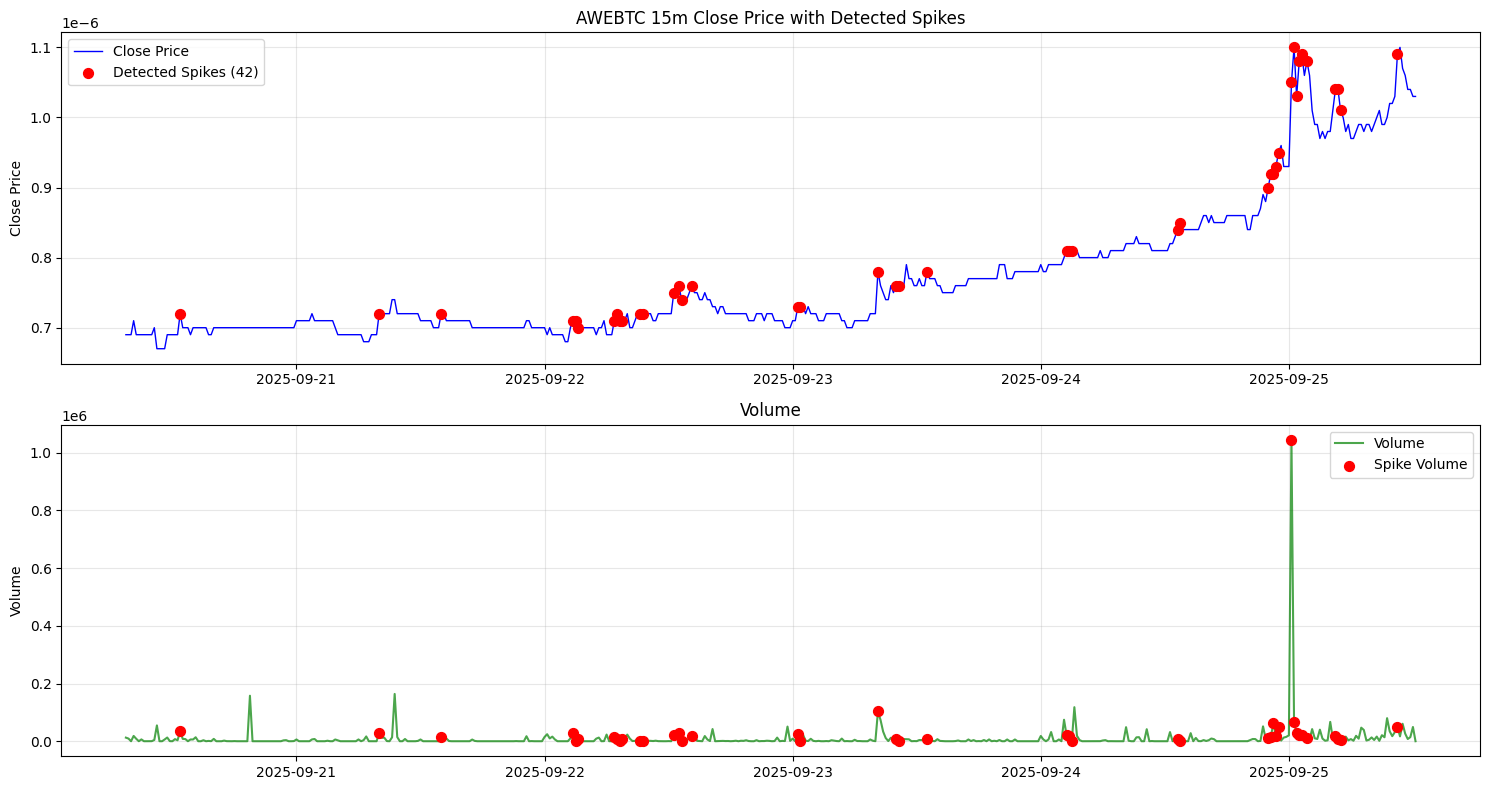

Total candles: 500
Spikes detected: 42
Detection rate: 0.0840

Price change statistics:
count    499.000000
mean       0.000894
std        0.013644
min       -0.063636
25%        0.000000
50%        0.000000
75%        0.000000
max        0.129032
Name: price_change, dtype: float64

Volume ratio statistics:
count    489.000000
mean       1.067087
std        2.101707
min        0.000000
25%        0.000000
50%        0.110085
75%        1.060403
max       12.000000
Name: volume_ratio, dtype: float64

Candles with price_change > 0.025: 21
Candles with volume_ratio > 2.50: 66
Candles with BOTH > thresholds: 8

Top 5 price changes:
              timestamp         close  price_change  volume_ratio
451 2025-09-25 00:15:00  1.050000e-06      0.129032      9.555182
291 2025-09-23 08:15:00  7.800000e-07      0.083333     10.583845
492 2025-09-25 10:30:00  1.090000e-06      0.058252      2.106617
454 2025-09-25 01:00:00  1.080000e-06      0.048544      0.197173
452 2025-09-25 00:30:00  1.100000e

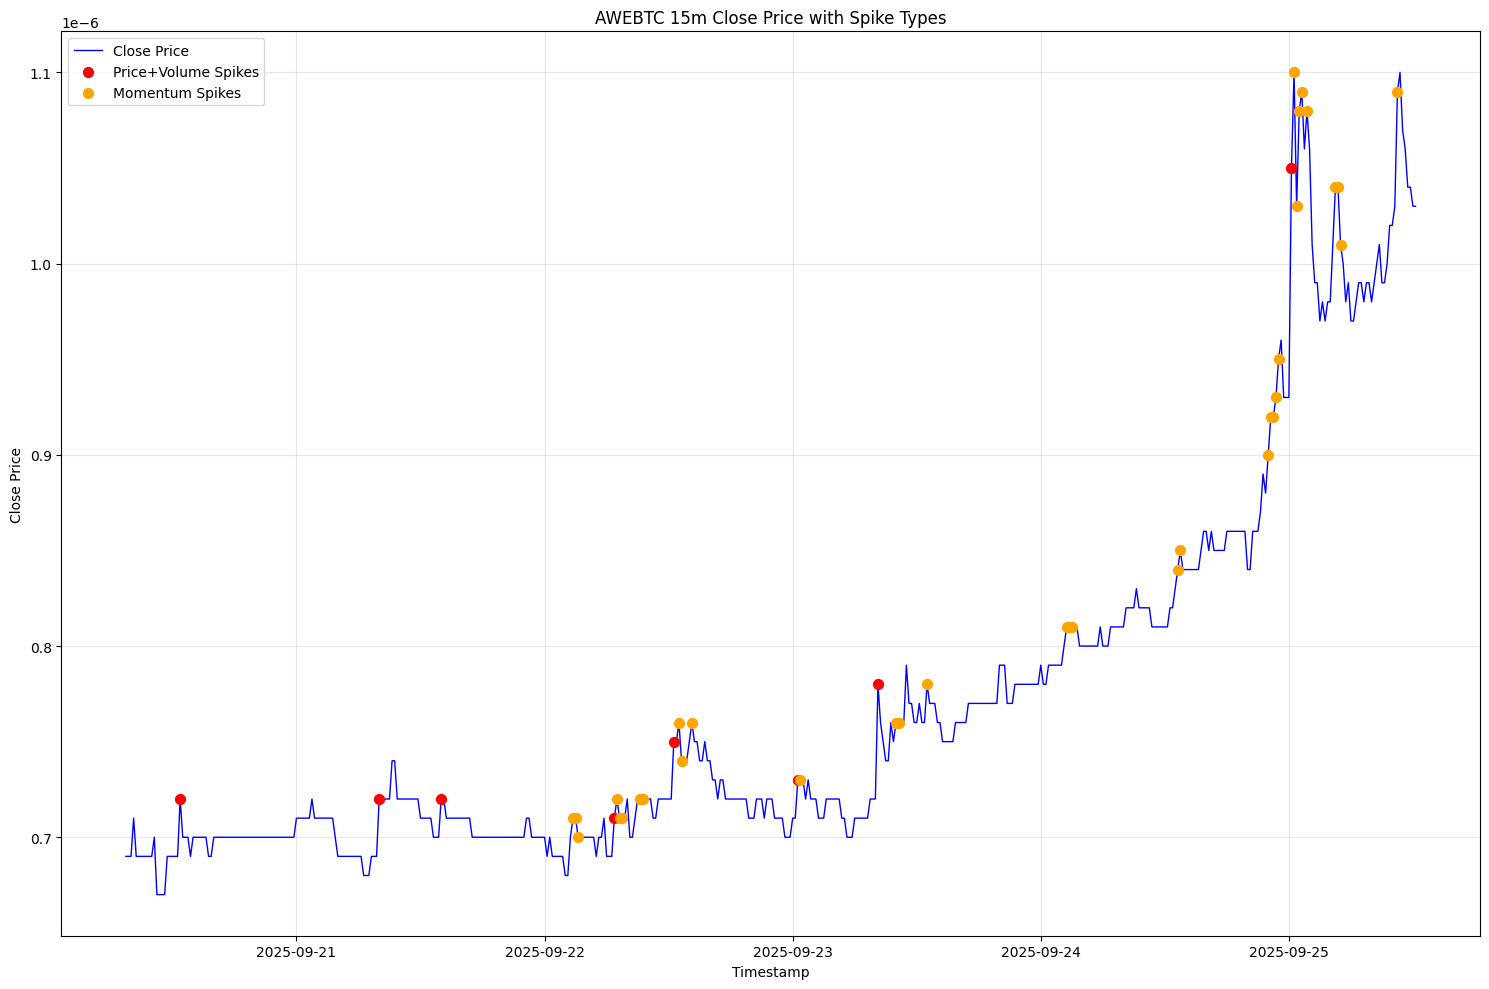

In [37]:
import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import warnings
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")


class SpikeHunter:
    """
    Unified spike detection system for cryptocurrency assets.
    Features:
    - Multiple detection algorithms (price+volume, momentum, RSI reversal, ML classifier)
    - Configurable sensitivity levels
    - Robust error handling
    - Performance optimized
    - Detailed summary and last spike reporting
    - Dynamic thresholding and advanced stats
    - ML-based spike prediction (RandomForest)
    """

    def __init__(
        self,
        model_path: str,
        momentum_threshold: float = 0.012,
        window: int = 12,
        rsi_oversold: int = 30,
        price_threshold: float = None,
        volume_threshold: float = None,
    ):
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold
        self.model = joblib.load(model_path)
        # If thresholds are provided, use them; otherwise, will be set dynamically
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold

    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        try:
            url = "https://api.binance.com/api/v3/klines"
            params = {"symbol": symbol, "interval": interval, "limit": limit}
            if end_time:
                params["endTime"] = end_time
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            df = pd.DataFrame(
                data,
                columns=[
                    "open_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "close_time",
                    "qav",
                    "num_trades",
                    "taker_base",
                    "taker_quote",
                    "ignore",
                ],
            )
            numeric_cols = ["open", "high", "low", "close", "volume"]
            df[numeric_cols] = df[numeric_cols].astype(float)
            df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
            df = df[["timestamp", "open", "high", "low", "close", "volume"]]
            return df.sort_values("timestamp").reset_index(drop=True)
        except Exception as e:
            raise Exception(f"Failed to fetch market data for {symbol}: {str(e)}")

    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def _add_all_features(self, df: pd.DataFrame) -> pd.DataFrame:
        # Basic price features
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = abs(df["close"] - df["open"])
        df["body_size_pct"] = df["body_size"] / df["open"]
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / df["open"]
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        # Rolling features
        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3
        df["price_ma"] = df["close"].rolling(window=effective_window).mean()
        df["price_std"] = df["close"].rolling(window=effective_window).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        # Volume features
        df["volume_ma"] = df["volume"].rolling(window=effective_window).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
            df["volume"].rolling(window=effective_window).std() + 1e-6
        )
        # Momentum indicators
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        # High/Low features
        df["high_low_ratio"] = df["high"] / df["low"]
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)
        # RSI
        df["rsi"] = self.calculate_rsi(df["close"])
        return df

    def _get_feature_matrix(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_cols = [
            "price_change",
            "price_change_abs",
            "body_size_pct",
            "upper_wick_ratio",
            "lower_wick_ratio",
            "is_bullish",
            "close_open_ratio",
            "price_zscore",
            "volume_ratio",
            "volume_zscore",
            "momentum_3",
            "momentum_5",
            "range_pct",
            "close_to_high",
            "close_to_low",
        ]
        for col in feature_cols:
            if col not in df.columns:
                df[col] = 0.0
        return df[feature_cols].fillna(0)

    def detect_spikes(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = self._add_all_features(df)
        df["spike_signal"] = 0
        df["spike_type"] = ""
        df["signal_strength"] = 0.0

        # ML-based spike prediction
        X = self._get_feature_matrix(df)
        try:
            ml_preds = self.model.predict(X)
        except Exception as e:
            ml_preds = np.zeros(len(df))

        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3

        # Use fixed thresholds if set, otherwise fallback to dynamic (will be set in run_analysis)
        price_thresh = (
            self.price_threshold
            if self.price_threshold is not None
            else df["price_change"].quantile(0.95)
        )
        volume_thresh = (
            self.volume_threshold
            if self.volume_threshold is not None
            else df["volume_ratio"].quantile(0.90)
        )

        for i in range(effective_window, len(df)):
            signal = 0
            signal_type = ""
            strength = 0.0
            current_price_change = df.loc[i, "price_change"]
            current_volume_ratio = df.loc[i, "volume_ratio"]
            current_rsi = df.loc[i, "rsi"]
            # Method 1: ML classifier
            if ml_preds[i] == 1:
                signal = 1
                signal_type = "ml_classifier"
                strength = 10.0
            # Method 2: Price + Volume Spike
            elif (
                current_price_change > price_thresh
                and current_volume_ratio > volume_thresh
            ):
                signal = 1
                signal_type = "price_volume"
                strength = min(current_price_change * current_volume_ratio * 10, 10.0)
            # Method 3: Momentum Detection
            elif i >= 5:
                recent_changes = df.loc[i - 3 : i, "price_change"]
                positive_moves = (recent_changes > self.momentum_threshold).sum()
                total_momentum = recent_changes.sum()
                if positive_moves >= 2 and total_momentum > price_thresh:
                    signal = 1
                    signal_type = "momentum"
                    strength = min(total_momentum * 20, 8.0)
            # Method 4: RSI Oversold Reversal
            elif (
                i >= 14
                and current_rsi > self.rsi_oversold
                and df.loc[i - 1, "rsi"] <= self.rsi_oversold
                and current_price_change > 0.008
            ):
                signal = 1
                signal_type = "rsi_reversal"
                strength = min(
                    (current_rsi - self.rsi_oversold) / 10 * current_price_change * 50,
                    6.0,
                )
            df.loc[i, "spike_signal"] = signal
            df.loc[i, "spike_type"] = signal_type
            df.loc[i, "signal_strength"] = strength
        return df

    def get_spike_summary(self, df: pd.DataFrame) -> Dict:
        spikes = df[df["spike_signal"] == 1]
        if len(spikes) == 0:
            return {
                "total_spikes": 0,
                "spike_rate": 0.0,
                "avg_price_change": 0.0,
                "avg_volume_ratio": 0.0,
                "avg_signal_strength": 0.0,
                "spike_types": {},
            }
        spike_types = spikes["spike_type"].value_counts().to_dict()
        return {
            "total_spikes": len(spikes),
            "spike_rate": len(spikes) / len(df),
            "avg_price_change": spikes["price_change"].mean(),
            "avg_volume_ratio": spikes["volume_ratio"].mean(),
            "avg_signal_strength": spikes["signal_strength"].mean(),
            "max_price_change": spikes["price_change"].max(),
            "max_volume_ratio": spikes["volume_ratio"].max(),
            "spike_types": spike_types,
            "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        }

    def run_analysis(self, symbol) -> Tuple[pd.DataFrame, Dict]:
        df = self.fetch_market_data(symbol, interval="15m", limit=500)
        # If fixed thresholds are not set, set them dynamically here (for backward compatibility)
        if self.price_threshold is None:
            self.price_threshold = df["price_change"].quantile(0.95)
        if self.volume_threshold is None:
            self.volume_threshold = df["volume_ratio"].quantile(0.90)
        df = self.detect_spikes(df)
        summary = self.get_spike_summary(df)
        return df, summary

    def get_last_spike_details(self, df, symbol="CFXUSDC", max_minutes_ago=30):
        spikes = df[df["spike_signal"] == 1]
        if len(spikes) == 0:
            return None
        last_spike = spikes.iloc[-1]
        current_time = pd.Timestamp.now(tz="UTC")
        spike_time = last_spike["timestamp"]
        if spike_time.tz is None:
            spike_time = spike_time.tz_localize("UTC")
        minutes_ago = (current_time - spike_time).total_seconds() / 60
        if minutes_ago > max_minutes_ago:
            return None
        return {
            "symbol": symbol,
            "timestamp": last_spike["timestamp"],
            "price": last_spike["close"],
            "price_change": last_spike["price_change"],
            "price_change_pct": last_spike["price_change"] * 100,
            "volume": last_spike["volume"],
            "volume_ratio": last_spike["volume_ratio"],
            "spike_type": last_spike["spike_type"],
            "signal_strength": last_spike["signal_strength"],
            "rsi": last_spike["rsi"],
            "body_size_pct": last_spike["body_size_pct"],
            "minutes_ago": minutes_ago,
        }


# Usage examples inherit from first cell


# Production analysis with fixed thresholds
hunter = SpikeHunter(
    model_path="../checkpoints/spikehunter_model_v1.pkl",
    price_threshold=FIXED_PRICE_THRESHOLD,
    volume_threshold=FIXED_VOLUME_THRESHOLD,
    # You can also set window/momentum_threshold/rsi_oversold if needed
    # window=12, momentum_threshold=0.012, rsi_oversold=30,
)
df, summary = hunter.run_analysis(symbol=symbol)

time_windows = [5, 15, 130]
spike_found = False
for window in time_windows:
    last_spike = hunter.get_last_spike_details(
        df, symbol=symbol, max_minutes_ago=window
    )
    if last_spike:
        print(
            f"🔥 LAST SPIKE DETECTED (within {window} minutes)\n"
            f"📅 Time: {last_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}\n"
            f"📈 Price: +{last_spike['price_change_pct']:.2f}%\n"
            f"📊 Volume: {last_spike['volume_ratio']:.1f}x above average\n"
            f"🏷️ Type: {last_spike['spike_type']}\n"
            f"⚡ Strength: {last_spike['signal_strength']:.1f}/10\n"
            f"⏰ Occurred: {last_spike['minutes_ago']:.1f} minutes ago"
        )
        spike_found = True
        break
if not spike_found:
    print(f"📊 No recent spikes detected in {symbol} within the last 30 minutes")
    all_spikes = df[df["spike_signal"] == 1]
    if len(all_spikes) > 0:
        last_any_spike = all_spikes.iloc[-1]
        # Ensure both are pandas Timestamps and handle tz-naive/tz-aware
        now = (
            pd.Timestamp.now(tz=last_any_spike["timestamp"].tz)
            if hasattr(last_any_spike["timestamp"], "tz")
            and last_any_spike["timestamp"].tz is not None
            else pd.Timestamp.now()
        )
        spike_time = last_any_spike["timestamp"]
        if pd.isnull(spike_time):
            print("Last spike timestamp is missing.")
        else:
            minutes_ago = (now - spike_time).total_seconds() / 60
            print(
                f"💡 Last spike was {minutes_ago / 60:.1f} hours ago at {spike_time.strftime('%Y-%m-%d %H:%M')}"
            )

# Show detected spikes
detected_spikes = df[df["spike_signal"] == 1]
print(f"\n🔥 Detected {len(detected_spikes)} spikes for {symbol}:")
if not detected_spikes.empty:
    print(
        detected_spikes[
            [
                "timestamp",
                "close",
                "price_change",
                "volume_ratio",
                "spike_type",
                "signal_strength",
            ]
        ].tail(10)
    )
else:
    print(f"No spikes detected for {symbol}.")

# --- Plot detected spikes with dynamic thresholds ---
plt.figure(figsize=(15, 8))
# Price plot
plt.subplot(2, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["spike_signal"] == 1]
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "close"],
        color="red",
        label=f"Detected Spikes ({len(spike_indices)})",
        zorder=5,
        s=50,
    )
plt.title(f"{symbol} 15m Close Price with Detected Spikes")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
# Volume plot
plt.subplot(2, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "volume"],
        color="red",
        label="Spike Volume",
        zorder=5,
        s=50,
    )
plt.title("Volume")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Additional stats and reporting ---
print(f"Total candles: {len(df)}")
print(f"Spikes detected: {len(detected_spikes)}")
if len(df) > 0:
    print(f"Detection rate: {len(detected_spikes) / len(df):.4f}")
print("\nPrice change statistics:")
print(df["price_change"].describe())
print("\nVolume ratio statistics:")
print(df["volume_ratio"].describe())
# Show how many candles exceed the thresholds
price_thresh = hunter.price_threshold
vol_thresh = hunter.volume_threshold
price_spikes = df[df["price_change"] > price_thresh]
vol_spikes = df[df["volume_ratio"] > vol_thresh]
both_spikes = df[
    (df["price_change"] > price_thresh) & (df["volume_ratio"] > vol_thresh)
]
print(f"\nCandles with price_change > {price_thresh:.3f}: {len(price_spikes)}")
print(f"Candles with volume_ratio > {vol_thresh:.2f}: {len(vol_spikes)}")
print(f"Candles with BOTH > thresholds: {len(both_spikes)}")
print("\nTop 5 price changes:")
print(
    df.nlargest(5, "price_change")[
        ["timestamp", "close", "price_change", "volume_ratio"]
    ]
)
print("\nTop 5 volume ratios:")
print(
    df.nlargest(5, "volume_ratio")[
        ["timestamp", "close", "price_change", "volume_ratio"]
    ]
)
print("\nMean close price:", df["close"].mean())
print("Mean volume:", df["volume"].mean())
print("Std price_change:", df["price_change"].std())
print("Std volume_ratio:", df["volume_ratio"].std())
print(
    "\nIf very few candles exceed the thresholds, consider lowering price_threshold or volume_threshold, or check if the symbol is inactive/illiquid."
)


# --- Plotting: Three Types of Detected Spikes ---
if not detected_spikes.empty:
    plt.figure(figsize=(15, 10))
    # Price + Volume spikes
    pv_spikes = df[df["spike_type"] == "price_volume"]
    # Momentum spikes
    mom_spikes = df[df["spike_type"] == "momentum"]
    # RSI reversal spikes
    rsi_spikes = df[df["spike_type"] == "rsi_reversal"]

    plt.plot(
        df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1
    )
    if not pv_spikes.empty:
        plt.scatter(
            pv_spikes["timestamp"],
            pv_spikes["close"],
            color="red",
            label="Price+Volume Spikes",
            s=50,
            zorder=5,
        )
    if not mom_spikes.empty:
        plt.scatter(
            mom_spikes["timestamp"],
            mom_spikes["close"],
            color="orange",
            label="Momentum Spikes",
            s=50,
            zorder=5,
        )
    if not rsi_spikes.empty:
        plt.scatter(
            rsi_spikes["timestamp"],
            rsi_spikes["close"],
            color="purple",
            label="RSI Reversal Spikes",
            s=50,
            zorder=5,
        )
    plt.title(f"{symbol} 15m Close Price with Spike Types")
    plt.xlabel("Timestamp")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No spikes detected to plot by type.")